<a href="https://colab.research.google.com/github/Siam19-ai/MachineLearning/blob/main/Forecasting(try%201).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/Siam19-ai/MachineLearning.git

Cloning into 'MachineLearning'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 26 (delta 8), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 94.22 KiB | 6.73 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import sklearn

In [8]:
df=pd.read_csv("/content/.config/Food Delivery Dataset.csv")

In [9]:
df['new_created_at'] = pd.to_datetime(df['created_at'])
df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])

/tmp/ipykernel_310/3261693086.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_created_at'] = pd.to_datetime(df['created_at'])
/tmp/ipykernel_310/3261693086.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['new_actual_delivery_time'] = pd.to_datetime(df['actual_delivery_time'])


In [11]:
df.isnull().sum()

,0
market_id,2
store_primary_category,22
order_protocol,3
total_items,0
subtotal,0
min_item_price,0
max_item_price,0
total_onshift_partners,74
total_busy_partners,74
total_outstanding_orders,74


In [12]:
df = df.sort_values('new_created_at').reset_index(drop=True)
df['delivery_time_minutes'] = (
    (df['new_actual_delivery_time'] - df['new_created_at'])
    .dt.total_seconds() / 60
)

# Calculate how much data we are losing
initial_count = len(df)
df = df[df["delivery_time_minutes"] >= 0]
deleted_count = initial_count - len(df)

print(f"Removed {deleted_count} rows ({deleted_count/initial_count:.2%}) due to negative delivery times.")

# Standard Academic Outlier Removal (Upper Bound)
Q1 = df["delivery_time_minutes"].quantile(0.25)
Q3 = df["delivery_time_minutes"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

# Filtering extreme high-end outliers
df = df[df["delivery_time_minutes"] <= upper_bound]

Removed 0 rows (0.00%) due to negative delivery times.


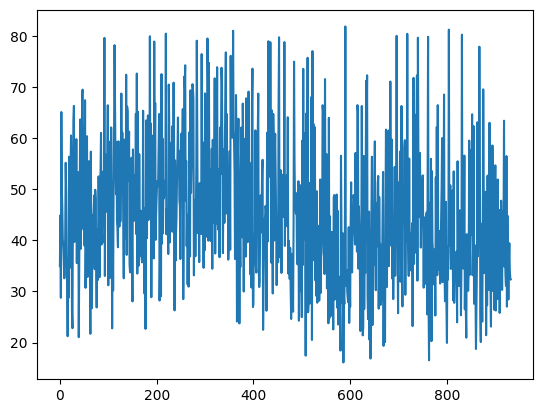

In [13]:
plt.plot(df["delivery_time_minutes"], linestyle ="solid")
plt.show()

ADF Statistic: -4.032
p-value: 0.001
Result: Data is Stationary (Good for ARIMA)


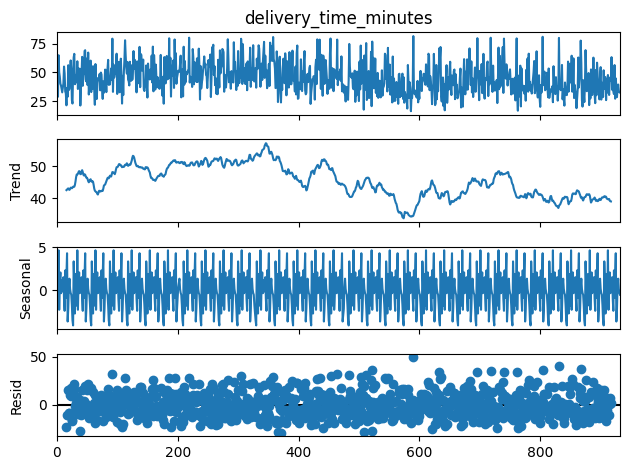

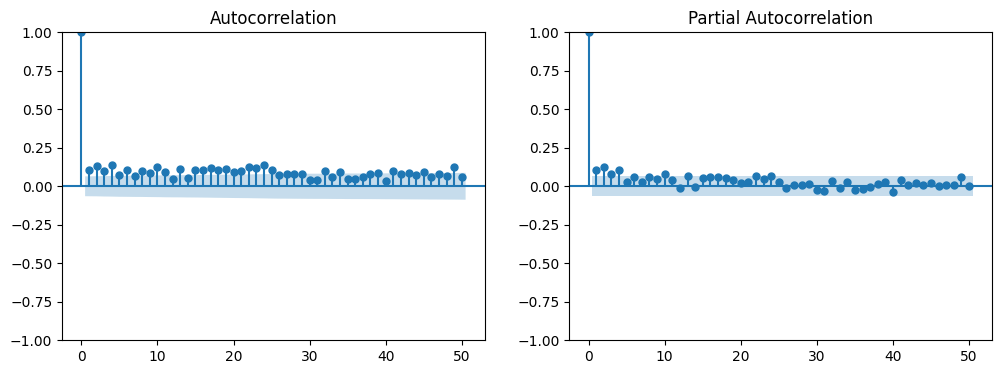

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def check_stationarity(data):
    result = adfuller(data)
    print(f'ADF Statistic: {result[0]:.3f}')
    print(f'p-value: {result[1]:.3f}')
    if result[1] <= 0.05:
        print("Result: Data is Stationary (Good for ARIMA)")
    else:
        print("Result: Data is Non-Stationary (Needs Differencing)")

check_stationarity(df["delivery_time_minutes"])

decomposition = seasonal_decompose(df["delivery_time_minutes"], model='additive', period=30)
decomposition.plot()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df["delivery_time_minutes"], lags=50, ax=ax1)
plot_pacf(df["delivery_time_minutes"], lags=50, ax=ax2)
plt.show()

In [ ]:
df["delivery_time_minutes"].index

Index([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,
       ...
       953, 954, 956, 957, 959, 960, 963, 965, 967, 973],
      dtype='int64', length=933)

**FORECASTING**

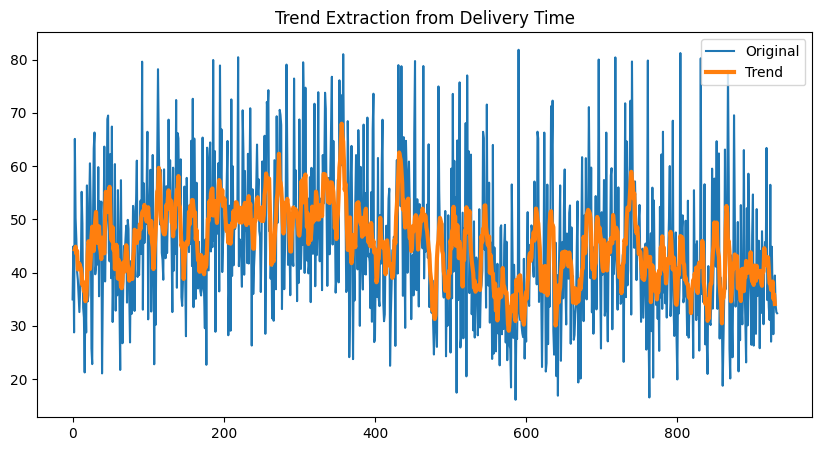

In [26]:
series = df['delivery_time_minutes']

# Estimate trend with rolling mean
df['trend'] = series.rolling(window=7, center=True).mean()

# Plot
plt.figure(figsize=(10,5))
plt.plot(series, label='Original')
plt.plot(df['trend'], label='Trend', linewidth=3)
plt.legend()
plt.title("Trend Extraction from Delivery Time")
plt.show()

In [27]:
from sklearn.linear_model import LinearRegression

# Remove NaN values caused by rolling mean
trend_df = df.dropna(subset=['trend']).copy()

# Create time index
trend_df['t'] = np.arange(len(trend_df))

X = trend_df[['t']]
y = trend_df['trend']

In [28]:
model = LinearRegression()
model.fit(X, y)

trend_df['trend_pred'] = model.predict(X)

In [29]:
future_steps = 30

future_t = np.arange(len(trend_df), len(trend_df) + future_steps).reshape(-1,1)

future_pred = model.predict(future_t)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


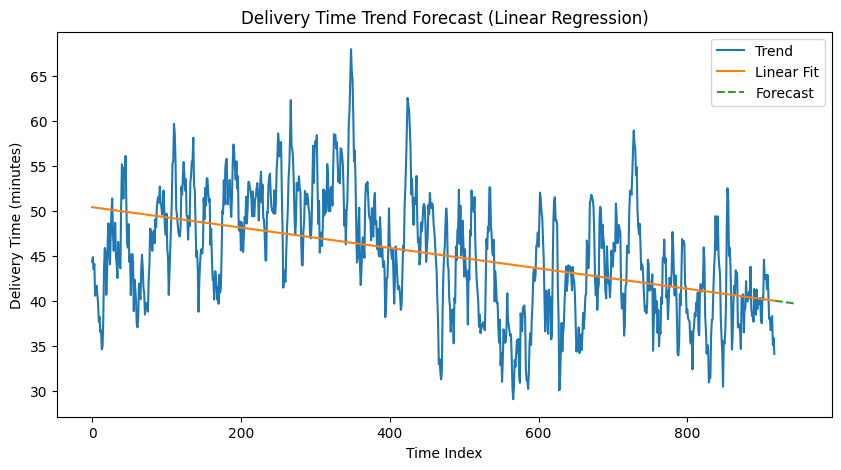

In [30]:
plt.figure(figsize=(10,5))

plt.plot(trend_df['t'], trend_df['trend'], label='Trend')
plt.plot(trend_df['t'], trend_df['trend_pred'], label='Linear Fit')

future_index = np.arange(len(trend_df), len(trend_df) + future_steps)

plt.plot(future_index, future_pred, '--', label='Forecast')

plt.legend()
plt.title("Delivery Time Trend Forecast (Linear Regression)")
plt.xlabel("Time Index")
plt.ylabel("Delivery Time (minutes)")
plt.show()